In [1]:
import pandas as pd

In [2]:
# Read the JSONL file
df = pd.read_json('visual-spatial-reasoning/random/dev.jsonl', lines=True)

df.head()

,image,image_link,caption,label,relation,annotator_id,vote_true_validator_id,vote_false_validator_id,reference_frame
0,000000239417.jpg,http://images.cocodataset.org/train2017/000000...,The bench is at the right side of the train.,0,at the right side of,1,[],"[2, 10, 1]",NaN
1,000000224670.jpg,http://images.cocodataset.org/train2017/000000...,The train contains the laptop.,1,contains,30,"[2, 67, 21]",[],NaN
2,000000266622.jpg,http://images.cocodataset.org/train2017/000000...,The bowl is at the left side of the banana.,1,at the left side of,2,"[13, 2, 1]",[],1.0
3,000000546264.jpg,http://images.cocodataset.org/train2017/000000...,The cat is under the motorcycle.,0,under,1,[],"[2, 55, 10]",NaN
4,000000490624.jpg,http://images.cocodataset.org/train2017/000000...,The bicycle is near the tv.,0,near,2,[],"[18, 2, 67]",NaN


In [3]:
df_train = pd.read_parquet('visual-spatial-reasoning/truthrl-sample/parquet/train.parquet')
df_train

,prompt,images,ability,reward_model,extra_info
0,[{'content': 'You are a visual spatial reasoni...,[{'image': 'file:///home/kalashkala/visual-spa...,visual_spatial_reasoning,"{'ground_truth': 'False', 'style': 'lexical'}","{'index': 0, 'split': 'train'}"
1,[{'content': 'You are a visual spatial reasoni...,[{'image': 'file:///home/kalashkala/visual-spa...,visual_spatial_reasoning,"{'ground_truth': 'False', 'style': 'lexical'}","{'index': 1, 'split': 'train'}"
2,[{'content': 'You are a visual spatial reasoni...,[{'image': 'file:///home/kalashkala/visual-spa...,visual_spatial_reasoning,"{'ground_truth': 'False', 'style': 'lexical'}","{'index': 2, 'split': 'train'}"
3,[{'content': 'You are a visual spatial reasoni...,[{'image': 'file:///home/kalashkala/visual-spa...,visual_spatial_reasoning,"{'ground_truth': 'False', 'style': 'lexical'}","{'index': 3, 'split': 'train'}"
4,[{'content': 'You are a visual spatial reasoni...,[{'image': 'file:///home/kalashkala/visual-spa...,visual_spatial_reasoning,"{'ground_truth': 'False', 'style': 'lexical'}","{'index': 4, 'split': 'train'}"
...,...,...,...,...,...
745,[{'content': 'You are a visual spatial reasoni...,[{'image': 'file:///home/kalashkala/visual-spa...,visual_spatial_reasoning,"{'ground_truth': 'True', 'style': 'lexical'}","{'index': 745, 'split': 'train'}"
746,[{'content': 'You are a visual spatial reasoni...,[{'image': 'file:///home/kalashkala/visual-spa...,visual_spatial_reasoning,"{'ground_truth': 'True', 'style': 'lexical'}","{'index': 746, 'split': 'train'}"
747,[{'content': 'You are a visual spatial reasoni...,[{'image': 'file:///home/kalashkala/visual-spa...,visual_spatial_reasoning,"{'ground_truth': 'True', 'style': 'lexical'}","{'index': 747, 'split': 'train'}"
748,[{'content': 'You are a visual spatial reasoni...,[{'image': 'file:///home/kalashkala/visual-spa...,visual_spatial_reasoning,"{'ground_truth': 'True', 'style': 'lexical'}","{'index': 748, 'split': 'train'}"


In [4]:
print(df_train.iloc[0]['images'])
print(df_train.iloc[0]['prompt'])
print(df_train.iloc[0]['reward_model'])

[{'image': 'file:///home/kalashkala/visual-spatial-reasoning/truthrl-sample/images/000000460783.jpg'}]
[{'content': "You are a visual spatial reasoning expert. Analyze the image and the statement. Answer exactly 'True', 'False', or 'I don't know'. Do not provide explanations.", 'role': 'system'}
 {'content': '<image>\nThe dog is under the bowl.', 'role': 'user'}]
{'ground_truth': 'False', 'style': 'lexical'}


In [4]:
# find maximium length of the prompt
max_caption_length = df_train['prompt'].apply(lambda x: len(x[1]['content'])).max()
max_task_length = df_train['prompt'].apply(lambda x: len(x[0]['content'])).max()
print(f"max_caption_length: {max_caption_length}")
print(f"max_task_length: {max_task_length}")
print(f"Total: {max_caption_length + max_task_length}")


max_caption_length: 69
max_task_length: 159
Total: 228


In [3]:
# Analysis of data:
df_test = pd.read_json('visual-spatial-reasoning/random/test.jsonl', lines=True)
df_dev = pd.read_json('visual-spatial-reasoning/random/dev.jsonl', lines=True)
df_train = pd.read_json('visual-spatial-reasoning/random/train.jsonl', lines=True)

print("Total number of examples:", len(df_test))
print("Number of examples per class:", df_test['label'].value_counts())

print("Total number of examples:", len(df_dev))
print("Number of examples per class:", df_dev['label'].value_counts())

print("Total number of examples:", len(df_train))
print("Number of examples per class:", df_train['label'].value_counts())

Total number of examples: 2195
Number of examples per class: label
1    1181
0    1014
Name: count, dtype: int64
Total number of examples: 1097
Number of examples per class: label
1    564
0    533
Name: count, dtype: int64
Total number of examples: 7680
Number of examples per class: label
1    3876
0    3804
Name: count, dtype: int64


In [4]:
# sample 750 training samples where 500 have label 0 and 500 have label 1

df_train_sampled_label_0 = df_train[df_train['label'] == 0].sample(n=375)
df_train_sampled_label_1 = df_train[df_train['label'] == 1].sample(n=375)
df_train_sampled = pd.concat([df_train_sampled_label_0, df_train_sampled_label_1])
df_train_sampled.to_json('visual-spatial-reasoning/truthrl-sample/data/train_sampled.jsonl', orient='records', lines=True)

# sample 750 test samples where 500 have label 0 and 500 have label 1
df_test_sampled_label_0 = df_test[df_test['label'] == 0].sample(n=375)
df_test_sampled_label_1 = df_test[df_test['label'] == 1].sample(n=375)
df_test_sampled = pd.concat([df_test_sampled_label_0, df_test_sampled_label_1])
df_test_sampled.to_json('visual-spatial-reasoning/truthrl-sample/data/test_sampled.jsonl', orient='records', lines=True)

In [ ]:
# verify the data

print("Train data")
print(len(df_train_sampled[df_train_sampled['label'] == 1]))
print(len(df_train_sampled[df_train_sampled['label'] == 0]))

print("Test data")
print(len(df_test_sampled[df_test_sampled['label'] == 1]))
print(len(df_test_sampled[df_test_sampled['label'] == 0]))

Train data
375
375
Test data
375
375


## Download Image Data

In [8]:
import json
import os
import requests
from tqdm import tqdm

def download_images(jsonl_files, output_dir):
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Collect all unique image links to avoid redundant downloads
    image_tasks = {}
    for file_path in jsonl_files:
        if not os.path.exists(file_path):
            print(f"Warning: File not found: {file_path}")
            continue
            
        with open(file_path, 'r') as f:
            for line in f:
                try:
                    data = json.loads(line)
                    image_name = data.get('image')
                    image_link = data.get('image_link')
                    if image_name and image_link:
                        image_tasks[image_name] = image_link
                except json.JSONDecodeError:
                    continue

    print(f"Found {len(image_tasks)} unique images to process.")
    
    # Download images
    for image_name, image_link in tqdm(image_tasks.items(), desc="Downloading images"):
        target_path = os.path.join(output_dir, image_name)
        
        # Skip if file already exists
        if os.path.exists(target_path):
            continue
            
        try:
            response = requests.get(image_link, timeout=15)
            if response.status_code == 200:
                with open(target_path, 'wb') as f:
                    f.write(response.content)
            else:
                print(f"\nFailed: {image_name} (Status: {response.status_code})")
        except Exception as e:
            print(f"\nError downloading {image_name}: {e}")

if __name__ == "__main__":
    DATA_FILES = [
        "/home/kalashkala/visual-spatial-reasoning/truthrl-sample/data/test_sampled.jsonl",
        "/home/kalashkala/visual-spatial-reasoning/truthrl-sample/data/train_sampled.jsonl"
    ]
    IMAGE_DIR = "/home/kalashkala/visual-spatial-reasoning/truthrl-sample/images"
    
    download_images(DATA_FILES, IMAGE_DIR)

Found 1353 unique images to process.


## Visualise Image

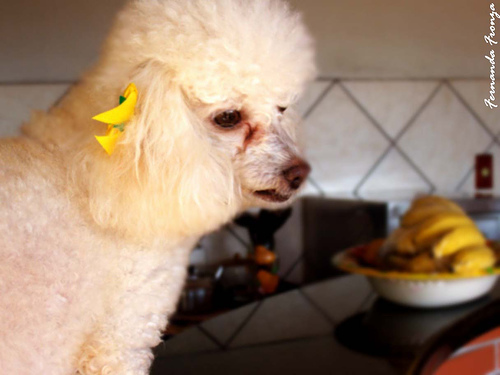

In [7]:
# create a code to visualise an image
from PIL import Image

# 1. Provide the path to your image
image_path = "/home/kalashkala/visual-spatial-reasoning/truthrl-sample/images/000000460783.jpg"

# 2. Open the image
img = Image.open(image_path)

# 3. Display it
img.show()